In [1]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn import preprocessing
import sys
import matplotlib.pyplot as plt
#from pandas.table.plotting import table # EDIT: see deprecation warnings below
import dataframe_image as dfi

%matplotlib inline

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
data = pd.read_excel("preliminary_162x127.xlsx")
data.head()

,1,2,3,4,5,6,7,8,9,10,...,118,119,120,121,122,123,124,125,126,127
0,NaN,Nr.,Lit.,Bez.,Einheiten E,Querschnittswerte - Section properties,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,b\nb,bw\nbw,h\nh,hf\nhf,"hh,top\nhh,top",...,"fcm,cyl\nfcm_cyl",fck\nfck,f´c\nfc_prime,Vct_ACI,Vs_ACI,Vcal_sACI,Vmax_ACI,rat_smax,VACI_cal,gmod_ACI
2,NaN,Nr.,Lit.,Bez.,E,NaN,NaN,NaN,NaN,NaN,...,"fcm,cyl\nfcm_cyl",fck\nfck,f´c\nfc_prime,Vct_ACI,Vs_ACI,Vcal_sACI,Vmax_ACI,rat_smax,VACI_cal,gmod_ACI
3,NaN,-,-,-,SI / A,mm,mm,mm,mm,mm,...,MPa,MPa,MPa,kN,kN,kN,kN,NaN,kN,NaN
4,Ahmad_1996_003_NNW-3,19,Ahmad; Xie; Yu (1996),NNW-3,A,"127,0","127,0","254,0",NaN,NaN,...,"41,5","37,5","39,1","26,82","41,06","67,88","134,08","0,506","67,88",1286


In [3]:
# #df_styled = data.head().style.background_gradient() #adding a gradient based on values in cell
# df_styled = data.head()
# dfi.export(df_styled,'rawDataHead.png', max_cols=-1)

In [4]:
data_mod = data[4:]
data_mod.head()

,1,2,3,4,5,6,7,8,9,10,...,118,119,120,121,122,123,124,125,126,127
4,Ahmad_1996_003_NNW-3,19,Ahmad; Xie; Yu (1996),NNW-3,A,"127,0","127,0","254,0",NaN,NaN,...,"41,5","37,5","39,1","26,82","41,06","67,88","134,08","0,506","67,88",1286
5,Ahmad_1996_006_NHW-3,22,Ahmad; Xie; Yu (1996),NHW-3,A,"127,0","127,0","254,0",NaN,NaN,...,"100,2","96,2","97,8","41,32","41,06","82,39","206,62","0,399","82,39",1245
6,Ahmad_1996_007_NHW-3a,23,Ahmad; Xie; Yu (1996),NHW-3a,A,"127,0","127,0","254,0",NaN,NaN,...,"91,8","87,8","89,4","39,51","53,38","92,89","197,53","0,470","92,89",1168
7,Ahmad_1996_008_NHW-3b,24,Ahmad; Xie; Yu (1996),NHW-3b,A,"127,0","127,0","254,0",NaN,NaN,...,"105,3","101,3","102,9","42,38","64,05","106,44","211,92","0,502","106,44",1154
8,Ahmad_1996_009_NHW-4,25,Ahmad; Xie; Yu (1996),NHW-4,A,"127,0","127,0","254,0",NaN,NaN,...,"100,8","96,8","98,4","41,45","41,06","82,51","207,26","0,398","82,51",1140


[Dummy Variables & One Hot Encoding]("https://medium.com/@subashdhoni86/dummy-variables-one-hot-encoding-ebf4f0391a2")

In [5]:
def myOHE(df, header):
    #df_list = df[header].values.tolist()
    #df_list = [str(val) for val in df[header].values]
    df_list = df[header].astype(str).tolist()
    myDict = {k:df_list.index(k) for k in df_list}
    #print (myDict)
    df_new = df
    le = preprocessing.LabelEncoder()
    df_new[header] = le.fit_transform(df_new[header].astype(str))
    # for head in myDict.keys():
    #     df_new[df_new[header]==head][head] = myDict[head]
    return df_new

In [6]:
oneHotEncodeColumns = [1, 3, 4,5, 29,47,61]

In [7]:
# df_new = myOHE(data_mod, 1)
df_new = data_mod
for col in oneHotEncodeColumns:
    df_new = myOHE(df_new, col)

/var/folders/3f/rcgzynbs7s93glm_6gx5m5r80000gn/T/ipykernel_3914/1691046204.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new[header] = le.fit_transform(df_new[header].astype(str))
/var/folders/3f/rcgzynbs7s93glm_6gx5m5r80000gn/T/ipykernel_3914/1691046204.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new[header] = le.fit_transform(df_new[header].astype(str))
/var/folders/3f/rcgzynbs7s93glm_6gx5m5r80000gn/T/ipykernel_3914/1691046204.py:9: SettingWithCopyWarning: 
A value is trying to be set 

# Python Pandas Decimal Mark EU to US

https://stackoverflow.com/questions/17531313/python-pandas-decimal-mark-eu-to-us

In [8]:
df_dropped = df_new.dropna(axis=1)
df_dropped

,1,2,3,4,5,6,7,8,15,16,...,118,119,120,121,122,123,124,125,126,127
4,0,19,0,60,0,"127,0","127,0","254,0",32258,"127,0",...,"41,5","37,5","39,1","26,82","41,06","67,88","134,08","0,506","67,88",1286
5,1,22,0,56,0,"127,0","127,0","254,0",32258,"127,0",...,"100,2","96,2","97,8","41,32","41,06","82,39","206,62","0,399","82,39",1245
6,2,23,0,57,0,"127,0","127,0","254,0",32258,"127,0",...,"91,8","87,8","89,4","39,51","53,38","92,89","197,53","0,470","92,89",1168
7,3,24,0,58,0,"127,0","127,0","254,0",32258,"127,0",...,"105,3","101,3","102,9","42,38","64,05","106,44","211,92","0,502","106,44",1154
8,4,25,0,59,0,"127,0","127,0","254,0",32258,"127,0",...,"100,8","96,8","98,4","41,45","41,06","82,51","207,26","0,398","82,51",1140
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,134,817,35,1,1,"200,0","200,0","300,0",60000,"150,0",...,"47,9","43,9","45,5","58,26","49,37","107,63","291,28","0,369","107,63",1585
157,135,819,35,2,1,"200,0","200,0","300,0",60000,"150,0",...,"50,4","46,4","48,0","59,82","159,73","219,55","299,09","0,734","219,55","0,867"
158,31,820,16,25,1,"655,0","155,0","820,0",207100,"282,6",...,"30,8","26,8","28,4","98,76","291,68","390,44","493,81","0,791","390,44",1683
159,32,821,16,27,1,"655,0","155,0","820,0",207100,"282,6",...,"31,4","27,4","29,0","99,73","218,76","318,49","498,65","0,639","318,49",1794


In [9]:
def punctuation_replace(punc_start, punc_end, df):
    df_out = df
    col = df_out.columns
    df_out[col] = df_out[col].astype(str)
    df_out[col] = df_out[col].apply(lambda x: x.str.replace(",","."))
    #df_out.to_csv(path, sep=';')
    #df_out.to_csv('./', sep=';')
    print(df_out)
    df_out[col] = df_out[col].astype(float)
    return df_out

In [10]:
df_exp = punctuation_replace(",",".", df_dropped)

     1    2   3   4   5      6      7      8       15     16   ...    118  \
4      0   19   0  60   0  127.0  127.0  254.0   32258  127.0  ...   41.5   
5      1   22   0  56   0  127.0  127.0  254.0   32258  127.0  ...  100.2   
6      2   23   0  57   0  127.0  127.0  254.0   32258  127.0  ...   91.8   
7      3   24   0  58   0  127.0  127.0  254.0   32258  127.0  ...  105.3   
8      4   25   0  59   0  127.0  127.0  254.0   32258  127.0  ...  100.8   
..   ...  ...  ..  ..  ..    ...    ...    ...     ...    ...  ...    ...   
156  134  817  35   1   1  200.0  200.0  300.0   60000  150.0  ...   47.9   
157  135  819  35   2   1  200.0  200.0  300.0   60000  150.0  ...   50.4   
158   31  820  16  25   1  655.0  155.0  820.0  207100  282.6  ...   30.8   
159   32  821  16  27   1  655.0  155.0  820.0  207100  282.6  ...   31.4   
160  147  874  41  17   1  300.0  300.0  450.0  135000  225.0  ...   20.6   

       119    120    121     122     123     124    125     126    127  
4 

/var/folders/3f/rcgzynbs7s93glm_6gx5m5r80000gn/T/ipykernel_3914/3227357917.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_out[col] = df_out[col].astype(str)
/var/folders/3f/rcgzynbs7s93glm_6gx5m5r80000gn/T/ipykernel_3914/3227357917.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_out[col] = df_out[col].apply(lambda x: x.str.replace(",","."))
/var/folders/3f/rcgzynbs7s93glm_6gx5m5r80000gn/T/ipykernel_3914/3227357917.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice

In [11]:
#df_exp.to_csv('./dataDropped_from_162by127_to_157rowsby84columns.csv', sep=';')

In [12]:
# for col in df_dropped.columns:
#     print(df_dropped[col].astype(float))

In [13]:
#df_dropped[[61]].astype(float)
#df_dropped[[61]]

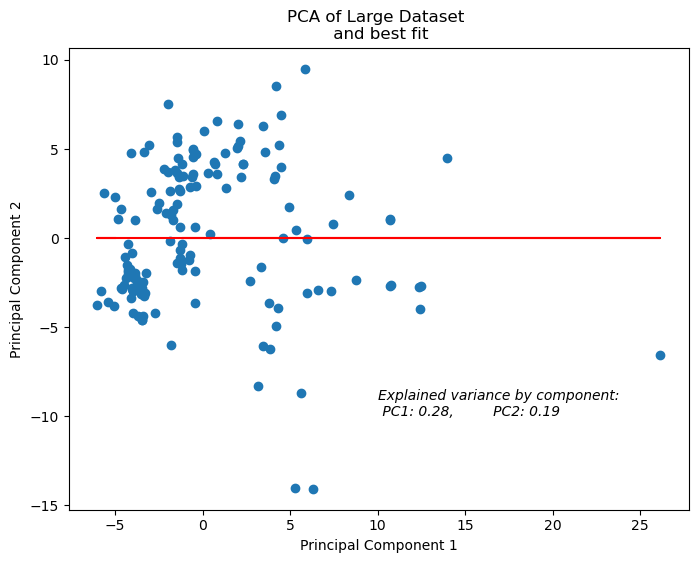

In [14]:
scaler = StandardScaler()
standardized_features = scaler.fit_transform(df_exp)

n_components = 2
pca = PCA(n_components=n_components)
principal_components = pca.fit_transform(standardized_features)
pc_df = pd.DataFrame(data=principal_components, columns=[f'PC{i+1}' for i in range(n_components)])

x, y = pc_df['PC1'], pc_df['PC2']

plt.figure(figsize=(8,6))
plt.scatter(x, y)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Large Dataset \n and best fit')

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red')

explained_variance = pca.explained_variance_ratio_
plt.text(10, -10, \
         f'Explained variance by component: \n PC1: {round(explained_variance[0],2)},\
         PC2: {round(explained_variance[1],2)}', style='italic')
#print(f'Explained variance by component: {explained_variance}')

plt.show()

In [15]:
plt.savefig("PC1_v_PC2_Large")

<Figure size 640x480 with 0 Axes>

In [16]:
pc_df

,PC1,PC2
0,-5.010655,2.309708
1,-6.051296,-3.773992
2,-5.823845,-2.967220
3,-5.069237,-3.822332
4,-5.401311,-3.577848
...,...,...
152,-4.825892,1.042292
153,-3.887528,1.000642
154,5.350332,0.440865
155,4.576533,-0.014884


In [17]:
scaler = StandardScaler()
standardized_features = scaler.fit_transform(df_exp)

n_components = 20
pca = PCA(n_components=n_components)
principal_components = pca.fit_transform(standardized_features)
pc_df = pd.DataFrame(data=principal_components, columns=[f'PC{i+1}' for i in range(n_components)])
#print(pc_df)
print(f'explained variance: {pca.explained_variance_}')
print(f'explained variance ratio: {pca.explained_variance_ratio_}')

explained variance: [23.84744779 15.94733474  8.28701229  6.16782254  3.86636334  2.87605289
  2.72164395  2.4731616   2.37885433  2.02026769  1.51734908  1.31463268
  1.13751193  1.0549322   1.02152068  0.9903712   0.79313595  0.75246002
  0.64365677  0.61235312]
explained variance ratio: [0.28208992 0.18863999 0.09802653 0.07295877 0.04573496 0.03402064
 0.03219415 0.02925487 0.02813931 0.02389762 0.01794862 0.0155507
 0.01345556 0.01247872 0.0120835  0.01171504 0.00938195 0.0089008
 0.00761377 0.00724349]


In [18]:
# Get the loadings
loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(pca.n_components_)], index=df_exp.columns)

print(loadings)

          PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
1    0.037231  0.041238 -0.075431  0.012919  0.311379  0.238188 -0.182632   
2    0.028844  0.035215 -0.074287  0.015866  0.275701  0.213207 -0.173148   
3    0.052881  0.025407 -0.067073 -0.036973  0.241573  0.262188 -0.168919   
4   -0.016478  0.088842 -0.154533  0.080174  0.034831 -0.019085  0.002504   
5    0.029132  0.034211 -0.124395  0.059994  0.040658 -0.032983  0.166536   
..        ...       ...       ...       ...       ...       ...       ...   
123  0.172393 -0.083909 -0.057127 -0.097014  0.001259  0.006417  0.062298   
124  0.059364 -0.188031  0.086608 -0.000231  0.015516  0.136741 -0.030751   
125  0.116693  0.082260 -0.188447 -0.050556 -0.042904 -0.008780 -0.066073   
126  0.157865 -0.133058  0.033783 -0.057642  0.029665  0.062730  0.051119   
127  0.059338  0.074250 -0.180801 -0.036481  0.071112 -0.189565  0.030461   

          PC8       PC9      PC10      PC11      PC12      PC13      PC14  

In [19]:
loadings.to_csv('./loadings_84columns_indexed_to_20_PCA.csv', sep=';')

In [20]:
PC1_sorted_loadings = loadings['PC1'].sort_values(ascending=False)
print(PC1_sorted_loadings)

94     0.177764
92     0.176744
72     0.176136
8      0.174659
26     0.174391
         ...   
95    -0.077047
90    -0.091581
32    -0.107637
49    -0.108218
102   -0.111281
Name: PC1, Length: 84, dtype: float64


In [21]:
print(PC1_sorted_loadings.sort_values(ascending=True))

102   -0.111281
49    -0.108218
32    -0.107637
90    -0.091581
95    -0.077047
         ...   
26     0.174391
8      0.174659
72     0.176136
92     0.176744
94     0.177764
Name: PC1, Length: 84, dtype: float64


In [23]:
print(abs(PC1_sorted_loadings).sort_values(ascending=False)[:10])

94     0.177764
92     0.176744
72     0.176136
8      0.174659
26     0.174391
25     0.174355
96     0.173630
97     0.172717
123    0.172393
15     0.172318
Name: PC1, dtype: float64


In [24]:
print(abs(loadings['PC1']).sort_values(ascending=False))

94     0.177764
92     0.176744
72     0.176136
8      0.174659
26     0.174391
         ...   
34     0.013636
113    0.012111
29     0.011664
28     0.000804
105    0.000164
Name: PC1, Length: 84, dtype: float64


In [25]:
sum(PC1_sorted_loadings)

5.4166718614828735

In [26]:
sum(abs(PC1_sorted_loadings))

7.78116230720527

In [27]:
PC2_sorted_loadings = loadings['PC2'].sort_values(ascending=False)
print(PC2_sorted_loadings)

88     0.205454
67     0.203514
104    0.178677
87     0.168829
103    0.159942
         ...   
117   -0.205411
120   -0.205419
119   -0.205419
118   -0.205419
60    -0.205425
Name: PC2, Length: 84, dtype: float64


In [28]:
print(abs(loadings['PC2']).sort_values(ascending=False))

88     0.205454
60     0.205425
118    0.205419
119    0.205419
120    0.205419
         ...   
47     0.023130
98     0.017894
93     0.017193
82     0.002371
112    0.002285
Name: PC2, Length: 84, dtype: float64


In [29]:
print(abs(loadings['PC2']).sort_values(ascending=False)[:10])

88     0.205454
60     0.205425
118    0.205419
119    0.205419
120    0.205419
117    0.205411
62     0.205242
67     0.203514
66     0.202901
124    0.188031
Name: PC2, dtype: float64


In [24]:
sum(PC2_sorted_loadings)

-1.2772585175749986

In [26]:
sum(abs(PC2_sorted_loadings))

7.6876732468634215

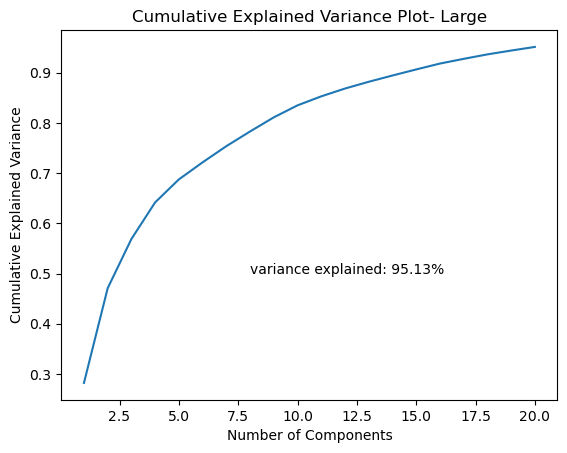

<Figure size 640x480 with 0 Axes>

In [25]:
# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot cumulative explained variance
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance Plot- Large')
plt.text(8,0.5,f'variance explained: {round(100*sum(pca.explained_variance_ratio_),2)}%')
plt.show();
plt.savefig("CumulativePlotRatio_Large.png");